# Understanding Masculine Identity

**Hanif Musaheb, Sara Chanaa, Luke Reiter**


## Introduction

Our team investigated masculinity using a dataset based off of a “masculinity survey” that asked 30 questions to men that are older than 18. This dataset was provided to the team via BrightSpace and while it does not say who ran this survey, and who gathered the data, our team believes it is trustworthy due to our professor posting and being confident in this data.

There is potential for bias in this data, as we also do not know who participated in this survey, but in the end our team thinks that it is a relatively true representation of men above the age of 18.

The data collected is mostly categorical variables, since respondents selected from a set range of answers. This limits some of the tests that can be run, but it still allows us to draw conclusions by cleaning the data, exploring patterns, and applying machine learning methods.

## Research Question

How does family affect a male's perception of masculinity?

More specifically, we examine whether respondents who identify fathers, mothers, or other family members as important influences report different levels of self-perceived masculinity.

In [58]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8,5)

## Loading the Data

We begin by loading the survey data and inspecting its structure. This helps us understand the available variables, their formatting, and any missing values that need to be handled.

In [59]:
df = pd.read_csv("masculinity_survey.csv")

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (1615, 98)


,Unnamed: 0,StartDate,EndDate,q0001,q0002,q0004_0001,q0004_0002,q0004_0003,q0004_0004,q0004_0005,...,q0035,q0036,race2,racethn4,educ3,educ4,age3,kids,orientation,weight
0,1,5/10/18 4:01,5/10/18 4:06,Somewhat masculine,Somewhat important,Not selected,Not selected,Not selected,Pop culture,Not selected,...,Middle Atlantic,Windows Desktop / Laptop,Non-white,Hispanic,College or more,College or more,35 - 64,No children,Gay/Bisexual,1.714026
1,2,5/10/18 6:30,5/10/18 6:53,Somewhat masculine,Somewhat important,Father or father figure(s),Not selected,Not selected,Not selected,Not selected,...,East North Central,iOS Phone / Tablet,White,White,Some college,Some college,65 and up,Has children,Straight,1.247120
2,3,5/10/18 7:02,5/10/18 7:09,Very masculine,Not too important,Father or father figure(s),Not selected,Not selected,Not selected,Not selected,...,East North Central,Windows Desktop / Laptop,White,White,College or more,College or more,35 - 64,Has children,Straight,0.515746
3,4,5/10/18 7:27,5/10/18 7:31,Very masculine,Not too important,Father or father figure(s),Mother or mother figure(s),Other family members,Not selected,Not selected,...,East North Central,Windows Desktop / Laptop,White,White,Some college,Some college,65 and up,Has children,No answer,0.600640
4,5,5/10/18 7:35,5/10/18 7:42,Very masculine,Very important,Not selected,Not selected,Other family members,Not selected,Not selected,...,East North Central,Windows Desktop / Laptop,White,White,College or more,College or more,35 - 64,No children,Straight,1.033400


In [60]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1615 entries, 0 to 1614
Data columns (total 98 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Unnamed: 0   1615 non-null   int64  
 1   StartDate    1615 non-null   str    
 2   EndDate      1615 non-null   str    
 3   q0001        1615 non-null   str    
 4   q0002        1615 non-null   str    
 5   q0004_0001   1615 non-null   str    
 6   q0004_0002   1615 non-null   str    
 7   q0004_0003   1615 non-null   str    
 8   q0004_0004   1615 non-null   str    
 9   q0004_0005   1615 non-null   str    
 10  q0004_0006   1615 non-null   str    
 11  q0005        1615 non-null   str    
 12  q0007_0001   1615 non-null   str    
 13  q0007_0002   1615 non-null   str    
 14  q0007_0003   1615 non-null   str    
 15  q0007_0004   1615 non-null   str    
 16  q0007_0005   1615 non-null   str    
 17  q0007_0006   1615 non-null   str    
 18  q0007_0007   1615 non-null   str    
 19  q0007_0008   1615

In [61]:
df.isna().sum().sort_values(ascending=False).head(20)

q0013         1566
q0015          873
q0012_0001     735
q0011_0002     735
q0010_0001     735
q0010_0002     735
q0010_0003     735
q0010_0004     735
q0010_0005     735
q0010_0006     735
q0010_0007     735
q0010_0008     735
q0011_0001     735
q0011_0003     735
q0011_0004     735
q0011_0005     735
q0012_0002     735
q0012_0003     735
q0012_0004     735
q0012_0005     735
dtype: int64

## Data Description

The dataset is made up mostly of categorical survey responses. Respondents selected answers from fixed categories, meaning most variables are non-numeric.

During our review of the dataset, we noticed:

- Some variables fall outside the scope of our project.
- Some multiple-choice questions are split across many columns.
- Many columns use `"Not selected"` for unchosen responses.
- Some questions only appear conditionally, creating missing values.
- Some columns appear redundant.

Because of this, cleaning and restructuring are necessary before analysis.

In [62]:
print(df.columns.tolist())

['Unnamed: 0', 'StartDate', 'EndDate', 'q0001', 'q0002', 'q0004_0001', 'q0004_0002', 'q0004_0003', 'q0004_0004', 'q0004_0005', 'q0004_0006', 'q0005', 'q0007_0001', 'q0007_0002', 'q0007_0003', 'q0007_0004', 'q0007_0005', 'q0007_0006', 'q0007_0007', 'q0007_0008', 'q0007_0009', 'q0007_0010', 'q0007_0011', 'q0008_0001', 'q0008_0002', 'q0008_0003', 'q0008_0004', 'q0008_0005', 'q0008_0006', 'q0008_0007', 'q0008_0008', 'q0008_0009', 'q0008_0010', 'q0008_0011', 'q0008_0012', 'q0009', 'q0010_0001', 'q0010_0002', 'q0010_0003', 'q0010_0004', 'q0010_0005', 'q0010_0006', 'q0010_0007', 'q0010_0008', 'q0011_0001', 'q0011_0002', 'q0011_0003', 'q0011_0004', 'q0011_0005', 'q0012_0001', 'q0012_0002', 'q0012_0003', 'q0012_0004', 'q0012_0005', 'q0012_0006', 'q0012_0007', 'q0013', 'q0014', 'q0015', 'q0017', 'q0018', 'q0019_0001', 'q0019_0002', 'q0019_0003', 'q0019_0004', 'q0019_0005', 'q0019_0006', 'q0019_0007', 'q0020_0001', 'q0020_0002', 'q0020_0003', 'q0020_0004', 'q0020_0005', 'q0020_0006', 'q0021_0001'

## Cleaning the Data

To focus on our research question, we keep the variables most relevant to masculinity perception and family influence.

We focus mainly on:

- `q0001`: self-perception of masculinity  
- `q0004_0001`: father or father figure(s)  
- `q0004_0002`: mother or mother figure(s)  
- `q0004_0003`: other family members  

We also remove unnecessary columns such as timestamps and the unnamed index column.

In [63]:
columns_to_drop = ["Unnamed: 0", "StartDate", "EndDate"]

df_clean = df.drop(columns=[col for col in columns_to_drop if col in df.columns], errors="ignore")

print("New shape:", df_clean.shape)

New shape: (1615, 95)


## Converting Family Variables to Binary Format

The family influence variables are stored as multiple-choice columns where selected responses contain text and unselected responses contain `"Not selected"`.

We convert these to:

- `1` = selected  
- `0` = not selected

In [64]:
family_cols = ["q0004_0001", "q0004_0002", "q0004_0003"]

for col in family_cols:
    df_clean[col] = df_clean[col].apply(
        lambda x: 0 if pd.isna(x) or str(x).strip().lower() == "not selected" else 1
    )

df_clean[family_cols].head()

,q0004_0001,q0004_0002,q0004_0003
0,0,0,0
1,1,0,0
2,1,0,0
3,1,1,1
4,0,0,1


## Encoding Masculinity Perception

We convert the self-perception masculinity question into an ordinal numeric scale:

- `4` = Very masculine  
- `3` = Somewhat masculine  
- `2` = Not very masculine  
- `1` = Not at all masculine  

Responses marked `"No answer"` are treated as missing values.

In [65]:
masculinity_mapping = {
    "Very masculine": 4,
    "Somewhat masculine": 3,
    "Not very masculine": 2,
    "Not at all masculine": 1,
    "No answer": np.nan
}

df_clean["Q1_score"] = df_clean["q0001"].map(masculinity_mapping)

df_clean[["q0001", "Q1_score"]].head()

,q0001,Q1_score
0,Somewhat masculine,3.0
1,Somewhat masculine,3.0
2,Very masculine,4.0
3,Very masculine,4.0
4,Very masculine,4.0


In [66]:
df_clean["Q1_score"].value_counts(dropna=False).sort_index()

Q1_score
1.0     32
2.0    131
3.0    826
4.0    612
NaN     14
Name: count, dtype: int64

## Exploratory Data Analysis

Our exploratory analysis focuses on family influence. We examine whether respondents who selected father figures, mother figures, or other family members as important influences report different masculinity self-ratings.

Because father influence appears most frequently in the dataset, it serves as a useful starting point for the analysis.

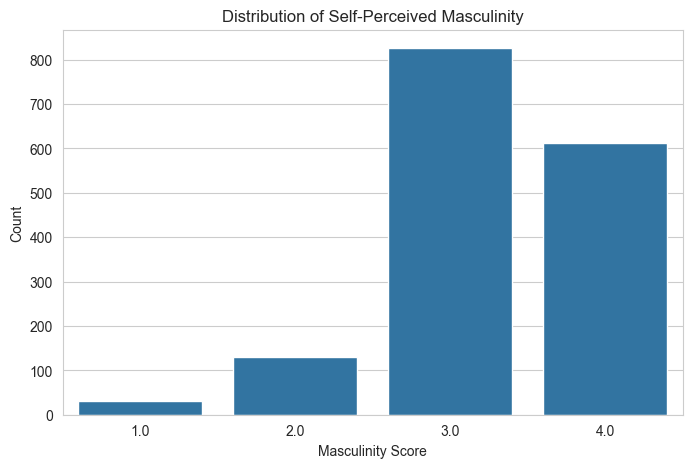

In [67]:
plt.figure(figsize=(8,5))
sns.countplot(data=df_clean, x="Q1_score")
plt.title("Distribution of Self-Perceived Masculinity")
plt.xlabel("Masculinity Score")
plt.ylabel("Count")
plt.show()

In [68]:
father_pct = df_clean["q0004_0001"].mean() * 100
mother_pct = df_clean["q0004_0002"].mean() * 100
other_family_pct = df_clean["q0004_0003"].mean() * 100

print(f"Father influence: {father_pct:.1f}%")
print(f"Mother influence: {mother_pct:.1f}%")
print(f"Other family influence: {other_family_pct:.1f}%")

Father influence: 68.7%
Mother influence: 40.6%
Other family influence: 34.9%


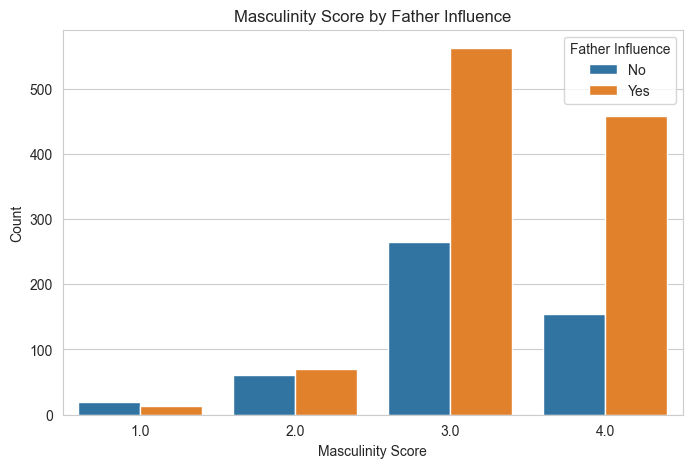

In [69]:
plt.figure(figsize=(8,5))
sns.countplot(data=df_clean, x="Q1_score", hue="q0004_0001")
plt.title("Masculinity Score by Father Influence")
plt.xlabel("Masculinity Score")
plt.ylabel("Count")
plt.legend(title="Father Influence", labels=["No", "Yes"])
plt.show()

Father influence was the strongest family-related variable in our initial review. This graph compares masculinity self-ratings between respondents who selected father influence and those who did not.

In [70]:
df_clean.groupby("q0004_0001")["Q1_score"].mean()

q0004_0001
0    3.110442
1    3.328196
Name: Q1_score, dtype: float64

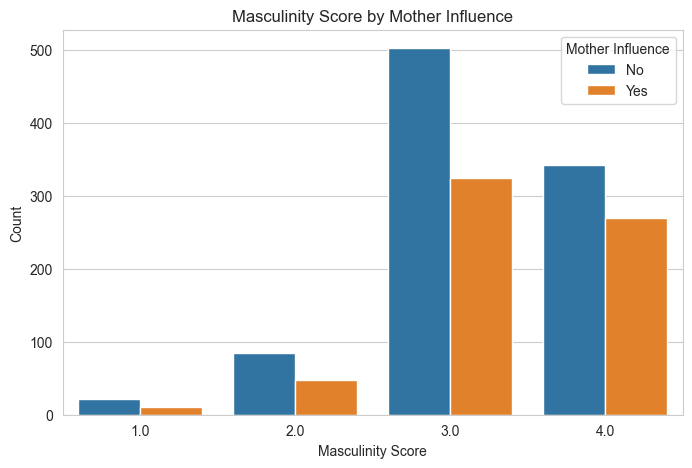

In [71]:
plt.figure(figsize=(8,5))
sns.countplot(data=df_clean, x="Q1_score", hue="q0004_0002")
plt.title("Masculinity Score by Mother Influence")
plt.xlabel("Masculinity Score")
plt.ylabel("Count")
plt.legend(title="Mother Influence", labels=["No", "Yes"])
plt.show()

In [72]:
df_clean.groupby("q0004_0002")["Q1_score"].mean()

q0004_0002
0    3.225263
1    3.311828
Name: Q1_score, dtype: float64

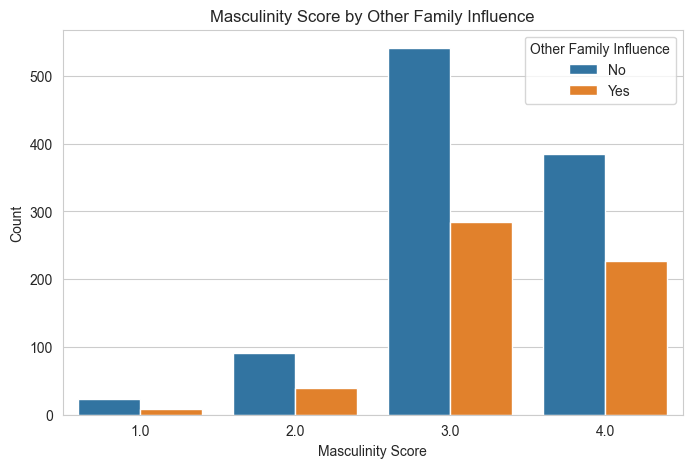

In [73]:
plt.figure(figsize=(8,5))
sns.countplot(data=df_clean, x="Q1_score", hue="q0004_0003")
plt.title("Masculinity Score by Other Family Influence")
plt.xlabel("Masculinity Score")
plt.ylabel("Count")
plt.legend(title="Other Family Influence", labels=["No", "Yes"])
plt.show()

In [74]:
df_clean.groupby("q0004_0003")["Q1_score"].mean()

q0004_0003
0    3.238462
1    3.301248
Name: Q1_score, dtype: float64

### Age
Below you can see the distribution of ages in the data, which we believe is important not as a direct measure of someones families but due to this survey being conducted in the the US particepents that are younger are much less likely to have kids of their own and the opposite is true for the older demographics. It will be interesting to see how this data matchs up with how masculine the men surveyed feel.

### Kids
Having children will be a much more direct way to see a surveyed persons family while the data doesn't say anthing specfic about ones family: how big?, divorced?, daughter or sons? It will provide critical data on wether or not they have kids.

### Orientation
I have included this one even though I am not sure how relevent it will be to what the families make up is. However it would be interesting to see if there are any divergences between the difference between a straight man and a straight dad and a gay man and a gay dad. What I am looking for is wether the change of being a father effects the two groups significantly differently.

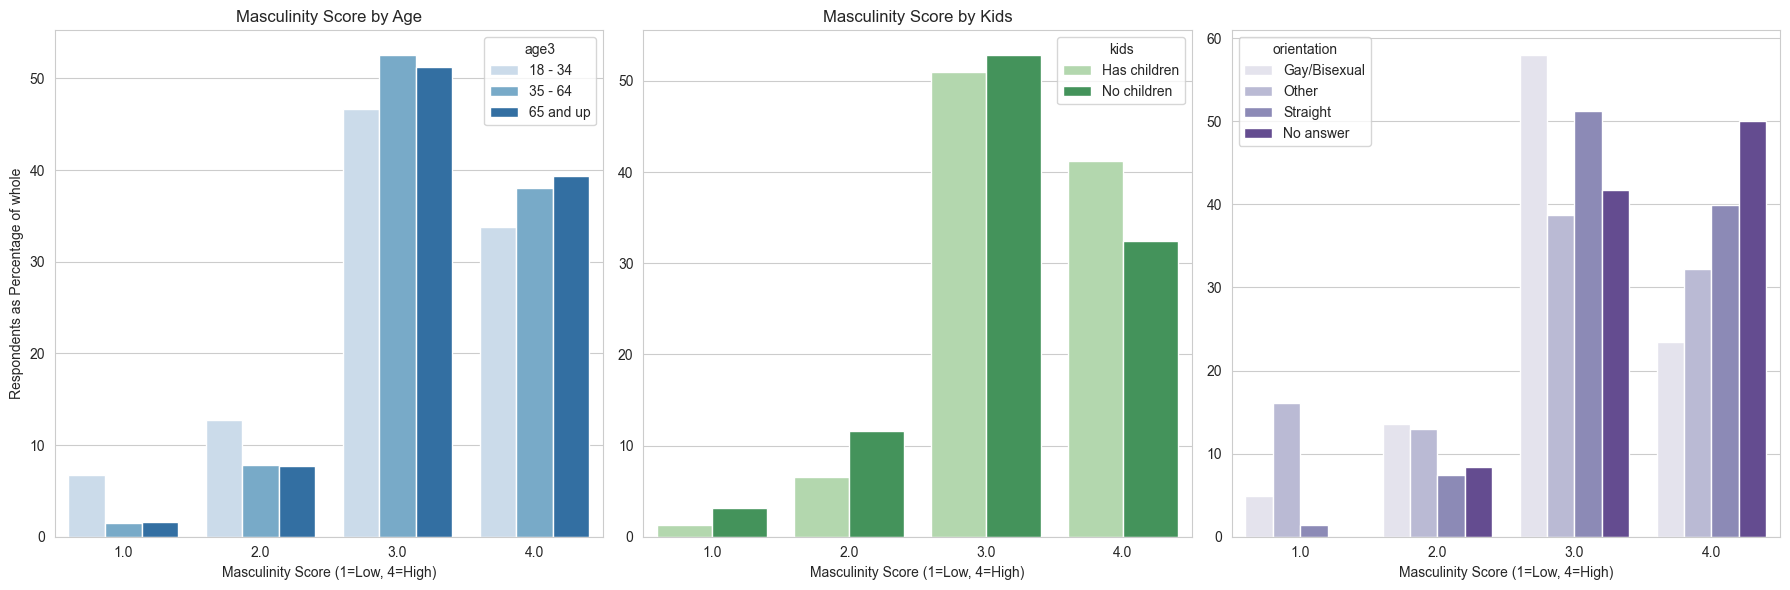

In [75]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))# 1x3 for the 3 plots on 1 row and figsize is the dimensions of that

# Age
age_pct = df_clean.groupby('age3')['Q1_score'].value_counts(normalize=True).mul(100).reset_index(name='Percentage')
sns.barplot(data=age_pct, x='Q1_score', y='Percentage', hue='age3', ax=axes[0], palette='Blues')
axes[0].set_title('Masculinity Score by Age')
axes[0].set_xlabel('Masculinity Score (1=Low, 4=High)')
axes[0].set_ylabel('Respondents as Percentage of whole')

# Kids
kids_pct = df_clean.groupby('kids')['Q1_score'].value_counts(normalize=True).mul(100).reset_index(name='Percentage')
sns.barplot(data=kids_pct, x='Q1_score', y='Percentage', hue='kids', ax=axes[1], palette='Greens')
axes[1].set_title('Masculinity Score by Kids')
axes[1].set_xlabel('Masculinity Score (1=Low, 4=High)')
axes[1].set_ylabel('') # Hiding the y label to keep it clean

# Orientation
orientation_pct = df_clean.groupby('orientation')['Q1_score'].value_counts(normalize=True).mul(100).reset_index(name='Percentage')
sns.barplot(data=orientation_pct, x='Q1_score', y='Percentage', hue='orientation', ax=axes[2], palette='Purples')
axes[2].set_xlabel('Masculinity Score (1=Low, 4=High)')
axes[2].set_ylabel('')

plt.tight_layout()
plt.show()

### Implications of the result above
You can see some trends emergung that may have been predictable before hand. In age it would seem as though you can see that there is a bias that students with a lower age are less likely have to a high masculinity. While older people seem to have higher percentage classifying themselves as more masculine.

Kids again backs this trend up showing a significant but marginal increased rate at classifying themselves as more masculine if the men had kids.

Finally for orientation it is little bit more confusing and it is not clear if there is a significant trend here which serves as useful information going forward with this project to possible not take that into consideration when trying to answer the main question of this project.



### Questions/Columns that are relevent to our question:
- `q1` In general, how masculine or “manly” do you feel? 
- `q2` How important is it to you that others see you as masculine?
- `q4` Where have you gotten your ideas about what it means to be a good man?
- `q7` How often would you say you do each of the following? 
- `q8` Which of the following do you worry about on a daily or near daily basis?
- `q9` Which of the following categories best describes your employment status?

In [76]:
q1=['q0001']
q2=['q0002']
q4=['q0004_0001', 'q0004_0002', 'q0004_0003', 'q0004_0004', 'q0004_0005', 'q0004_0006']
q5=['q0005']
q7=['q0007_0001', 'q0007_0002', 'q0007_0003', 'q0007_0004',
       'q0007_0005', 'q0007_0006', 'q0007_0007', 'q0007_0008', 'q0007_0009',
       'q0007_0010', 'q0007_0011']
q8=['q0008_0001', 'q0008_0002', 'q0008_0003',
       'q0008_0004', 'q0008_0005', 'q0008_0006', 'q0008_0007', 'q0008_0008',
       'q0008_0009', 'q0008_0010', 'q0008_0011', 'q0008_0012']
q9=['q0009']


In [89]:
def plot_checkbox_percentages(df, question_cols, labels_dict, title, group_col='kids',values_to_drop=["Not selected"]):
    """
    a general function to plot the multiple choice question data to bar graphs
    """
    temp_df = df.copy()# create a copy to not modify original data frame
    temp_df[question_cols] = temp_df[question_cols].replace(values_to_drop, np.nan)  #replace not selected with NAN
    totals_by_group = temp_df[group_col].value_counts()#total population in each demographic
    checked_counts = temp_df.groupby(group_col)[question_cols].count() # count how many people checked each option, grouped by the demographic
    percentages_df = checked_counts.div(totals_by_group, axis=0) * 100 #calculate percentage
    
    # reshape the dataframe for Seaborn
    percentages_df = percentages_df.reset_index() 
    plot_df = percentages_df.melt(id_vars=group_col, var_name='Question', value_name='Percentage')
    
    
    plot_df['Question'] = plot_df['Question'].map(labels_dict)# apply the labels
    

    plt.figure(figsize=(12, 8)) 
    sns.barplot(data=plot_df, x='Percentage', y='Question', hue=group_col, palette='Set2')
    plt.title(title)
    plt.xlabel('Percentage of Demographic Group (%)')
    plt.ylabel('Checkbox Options')
    
    plt.tight_layout()
    plt.show()


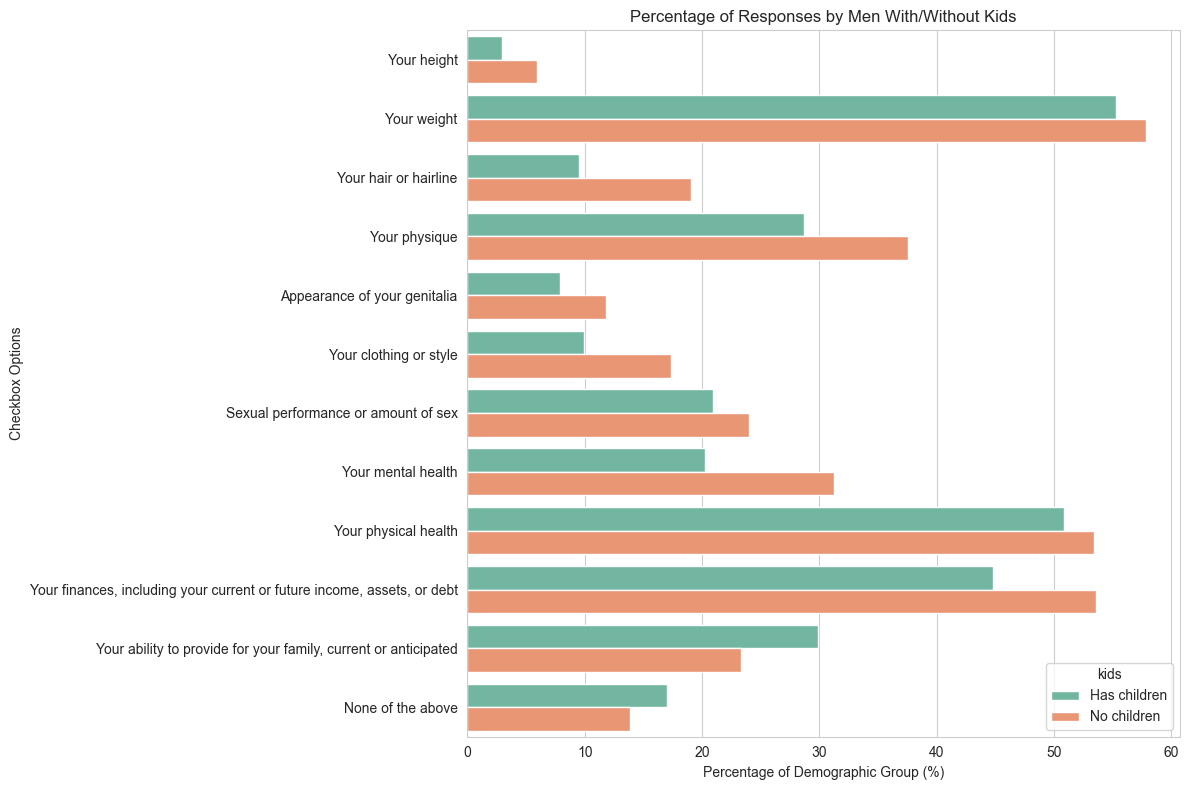

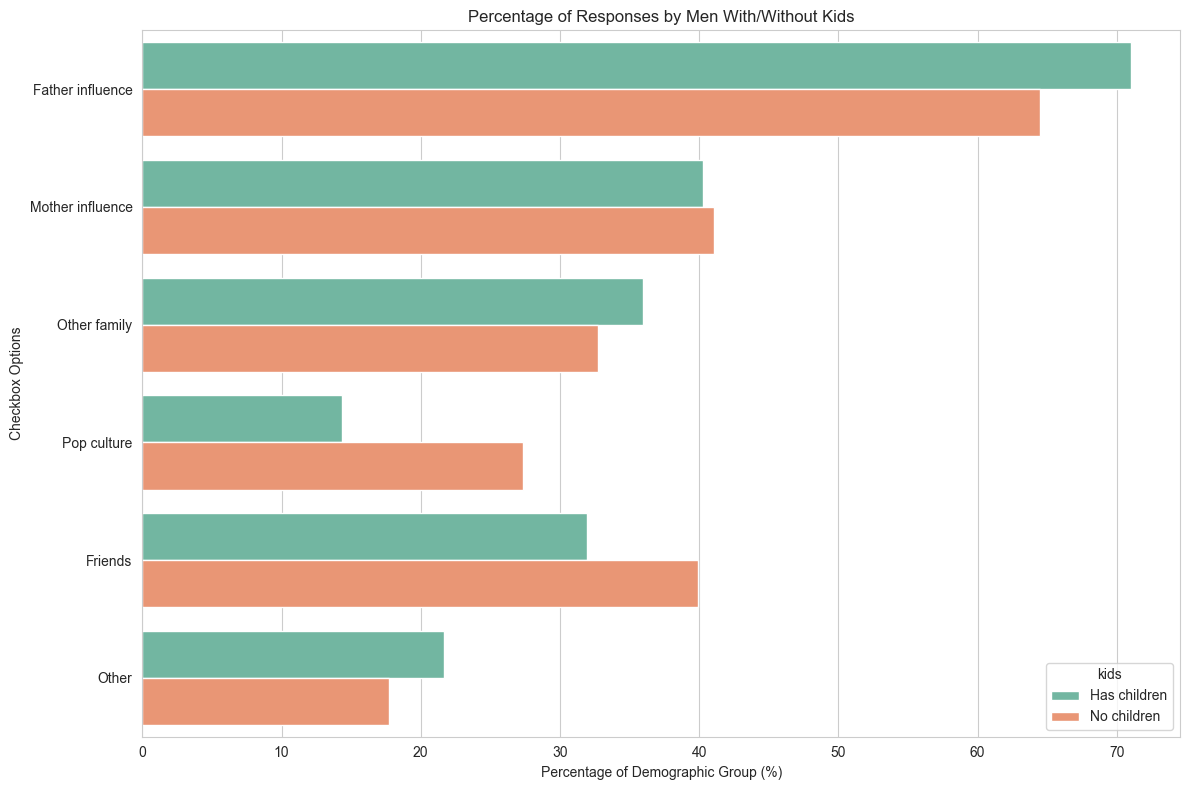

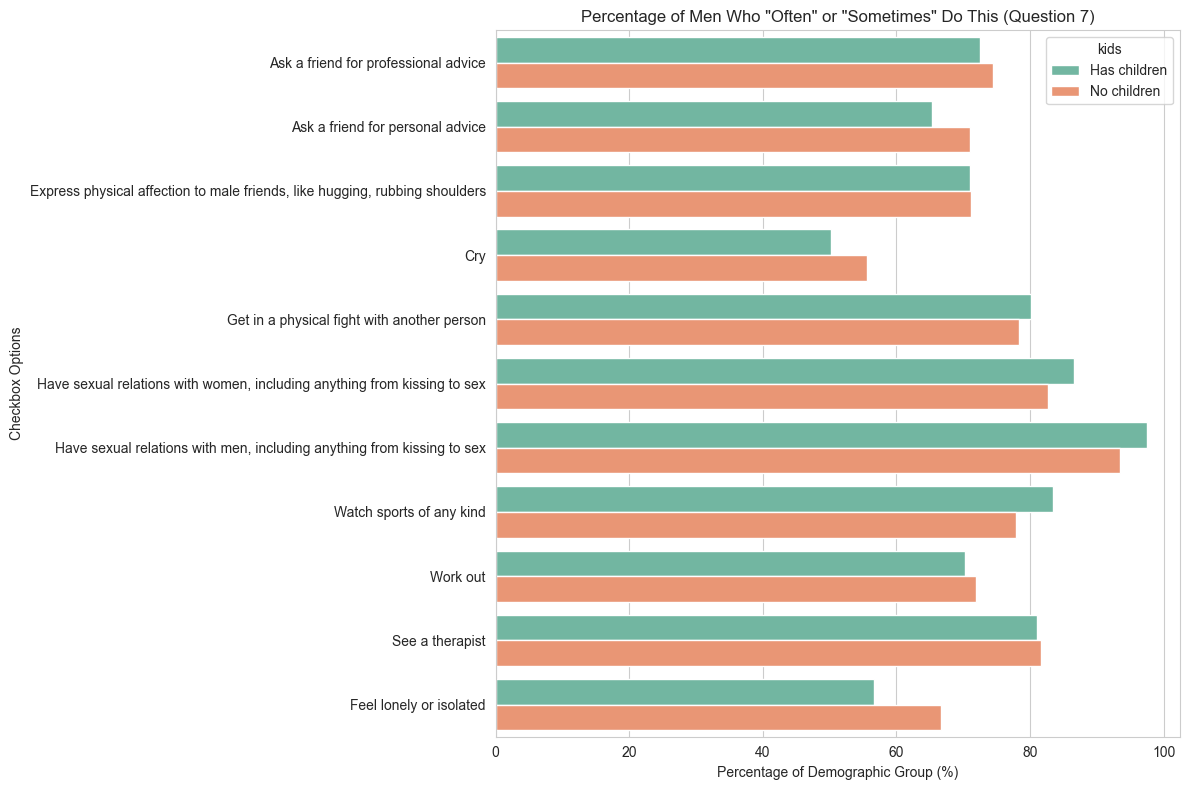

In [90]:
# 1. Define your variables
q8 = ['q0008_0001', 'q0008_0002', 'q0008_0003', 'q0008_0004', 
      'q0008_0005', 'q0008_0006', 'q0008_0007', 'q0008_0008', 
      'q0008_0009', 'q0008_0010', 'q0008_0011', 'q0008_0012']

q8_labels = {
    'q0008_0001': 'Your height',
    'q0008_0002': 'Your weight',
    'q0008_0003': 'Your hair or hairline',
    'q0008_0004': 'Your physique',
    'q0008_0005': 'Appearance of your genitalia',
    'q0008_0006': 'Your clothing or style',
    'q0008_0007': 'Sexual performance or amount of sex',
    'q0008_0008': 'Your mental health',
    'q0008_0009': 'Your physical health',
    'q0008_0010': 'Your finances, including your current or future income, assets, or debt',
    'q0008_0011': 'Your ability to provide for your family, current or anticipated',
    'q0008_0012': 'None of the above'
}


q4 = ['q0004_0001', 'q0004_0002', 'q0004_0003', 'q0004_0004', 'q0004_0005', 'q0004_0006']

q4_labels = {
    'q0004_0001': 'Father influence',
    'q0004_0002': 'Mother influence',
    'q0004_0003': 'Other family', 
    'q0004_0004': 'Pop culture',
    'q0004_0005': 'Friends',
    'q0004_0006': 'Other',
}

q7 = ['q0007_0001', 'q0007_0002', 'q0007_0003', 'q0007_0004', 
      'q0007_0005', 'q0007_0006', 'q0007_0007', 'q0007_0008', 
      'q0007_0009', 'q0007_0010', 'q0007_0011']

q7_labels = {
    'q0007_0001': 'Ask a friend for professional advice',
    'q0007_0002': 'Ask a friend for personal advice',
    'q0007_0003': 'Express physical affection to male friends, like hugging, rubbing shoulders',
    'q0007_0004': 'Cry',
    'q0007_0005': 'Get in a physical fight with another person',
    'q0007_0006': 'Have sexual relations with women, including anything from kissing to sex',
    'q0007_0007': 'Have sexual relations with men, including anything from kissing to sex',
    'q0007_0008': 'Watch sports of any kind',
    'q0007_0009': 'Work out',
    'q0007_0010': 'See a therapist',
    'q0007_0011': 'Feel lonely or isolated'
}



plot_checkbox_percentages(
    df=pd.read_csv('masculinity_survey.csv'), 
    question_cols=q8, 
    labels_dict=q8_labels, 
    title='Percentage of Responses by Men With/Without Kids',
    group_col='kids'
    
)
plot_checkbox_percentages(
    df=pd.read_csv('masculinity_survey.csv'), 
    question_cols=q4, 
    labels_dict=q4_labels, 
    title='Percentage of Responses by Men With/Without Kids',
    group_col='kids'
)


plot_checkbox_percentages(
    df=pd.read_csv('masculinity_survey.csv'), 
    question_cols=q7, 
    labels_dict=q7_labels, 
    group_col='kids', 
    title='Percentage of Men Who "Often" or "Sometimes" Do This (Question 7)',
    values_to_drop=["Never", "Rarely", "No answer"] # Drops these so only Often/Sometimes are counted
)